House-Price-Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Bengaluru_House_Data.csv').copy()

In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


# 1. Checking missing values


In [6]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [7]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


#2. Droping useless cloumns

In [8]:
df=df.drop(['area_type','availability','society'], axis=1)
df.head()


,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Kothanur,2 BHK,1200,2.0,1.0,51.00


#3. Droping remaining null rows

In [9]:
df=df.dropna()
df.isnull().sum()

,0
location,0
size,0
total_sqft,0
bath,0
balcony,0
price,0


In [10]:
df.shape

(12710, 6)

#4. Handling size column

In [11]:
df['bhk']=df['size'].apply(lambda x: int(x.split(' ')[0]))
df['bhk'].value_counts()

,count
bhk,
2,5480
3,4655
4,1238
1,648
5,299
6,192
7,85
8,68
9,34


#5. Fixing total_sqft

In [12]:
df['total_sqft'].unique()[:30]

array(['1056', '2600', '1440', '1521', '1200', '1170', '1310', '1800',
       '2785', '1000', '1100', '2250', '1175', '1180', '1540', '2770',
       '600', '1755', '2800', '1767', '510', '1250', '660', '1610',
       '1151', '1025', '2100 - 2850', '1075', '1760', '1693'],
      dtype=object)

In [13]:
def convert_sqft(x):
  t=x.split('-')
  if(len(t)==2):
    return (float(t[0])+float(t[1]))/2
  try:
    return float(x)
  except:
    return None

In [14]:
df['total_sqft']=df['total_sqft'].apply(convert_sqft)
df['total_sqft'].head(10)

,total_sqft
0,1056.0
1,2600.0
2,1440.0
3,1521.0
4,1200.0
5,1170.0
8,1310.0
10,1800.0
11,2785.0
12,1000.0


In [15]:
df=df.dropna(subset=['total_sqft'])
df.shape

(12668, 7)

#6. Feature Engineering

In [16]:
df['price_per_sqft']=df['price']*100000/df['total_sqft']
df.head()

,location,size,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2,4250.000000


In [17]:
print(df['location'].nunique())
df['location'].value_counts()

1259


,count
location,
Whitefield,513
Sarjapur Road,372
Electronic City,300
Kanakpura Road,259
Thanisandra,230
...,...
Jaladarsini Layout,1
Manganahalli,1
Housing Board Layout Vijay Nagar,1


In [18]:
total=df['location'].value_counts()
rare=total[total<10].index
df['location']=df['location'].apply(lambda x: 'others' if x in rare else x)

print(df['location'].nunique())
df['location'].value_counts()

248


,count
location,
others,2636
Whitefield,513
Sarjapur Road,372
Electronic City,300
Kanakpura Road,259
...,...
1st Block Koramangala,10
Thyagaraja Nagar,10
Gunjur Palya,10


#7. Removing Outliers

In [19]:
df['bhk'] = df['size'].astype(str).apply(lambda x: int(x.split(' ')[0]))
df.columns

Index(['location', 'size', 'total_sqft', 'bath', 'balcony', 'price', 'bhk',
       'price_per_sqft'],
      dtype='object')

In [20]:
df = df[~(df['total_sqft']/df['bhk'] < 300)]
df.shape

(12013, 8)

In [21]:
def remove_price_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf['price_per_sqft'])
        st = np.std(subdf['price_per_sqft'])
        reduced = subdf[
            (subdf['price_per_sqft'] > (m - st)) &
            (subdf['price_per_sqft'] <= (m + st))
        ]
        df_out = pd.concat([df_out, reduced], ignore_index=True)
    return df_out

df = remove_price_outliers(df)
df.shape

(9828, 8)

In [22]:
df = df[df['bhk'] <= 10]
df.shape

(9826, 8)

In [23]:
df = df[df['bath'] < df['bhk'] + 2]
df.shape

(9745, 8)

In [24]:
df = df.drop('size', axis=1)
df.head()

,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Devarachikkanahalli,1250.0,2.0,3.0,44.0,3,3520.000000
1,Devarachikkanahalli,1250.0,2.0,2.0,40.0,2,3200.000000
2,Devarachikkanahalli,1200.0,2.0,2.0,83.0,2,6916.666667
3,Devarachikkanahalli,1170.0,2.0,2.0,40.0,2,3418.803419
4,Devarachikkanahalli,1425.0,2.0,2.0,65.0,3,4561.403509


#8. EDA

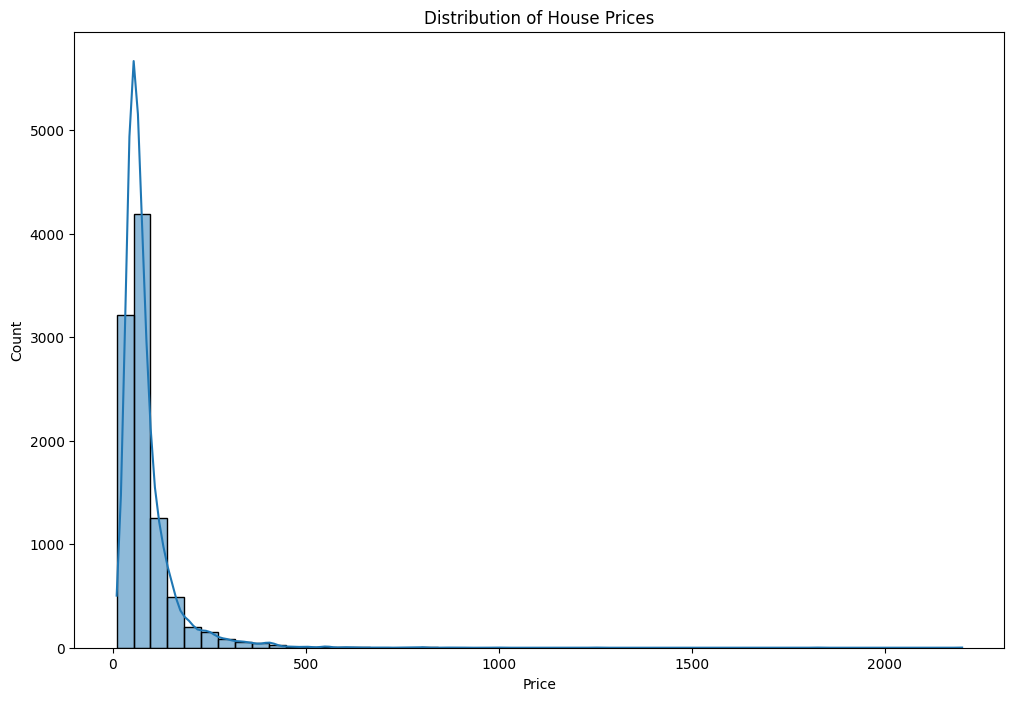

In [25]:
plt.figure(figsize=(12, 8))
sns.histplot(df['price'],bins=50,kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

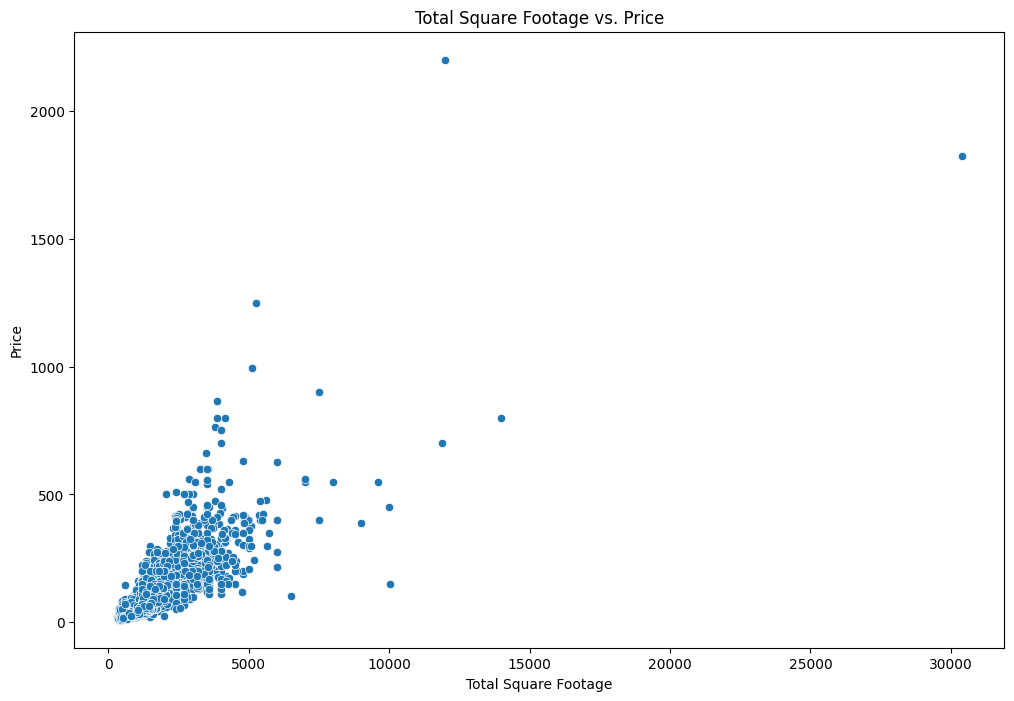

In [26]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='total_sqft', y='price', data=df)
plt.title('Total Square Footage vs. Price')
plt.xlabel('Total Square Footage')
plt.ylabel('Price')
plt.show()

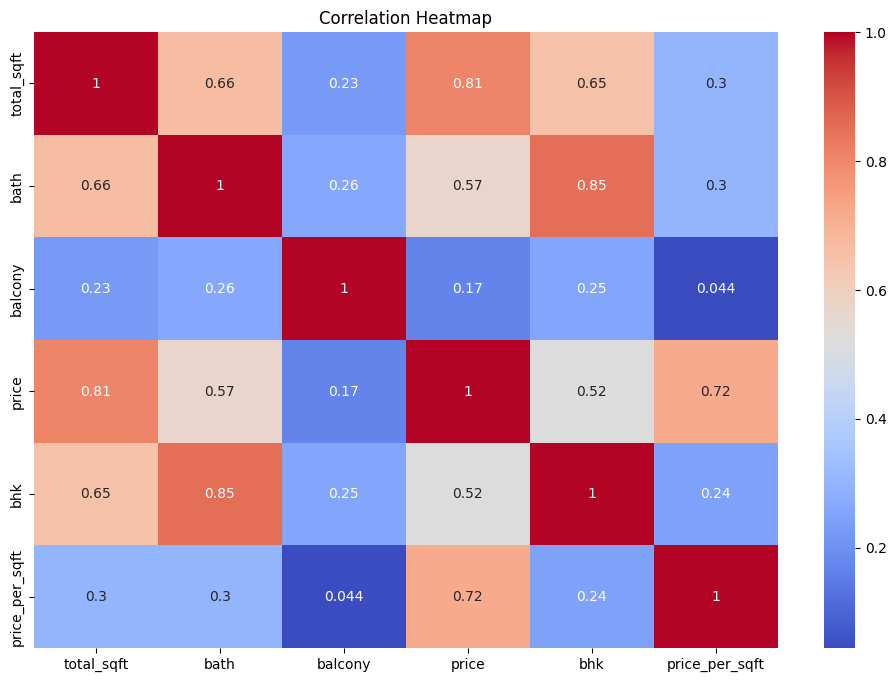

In [27]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

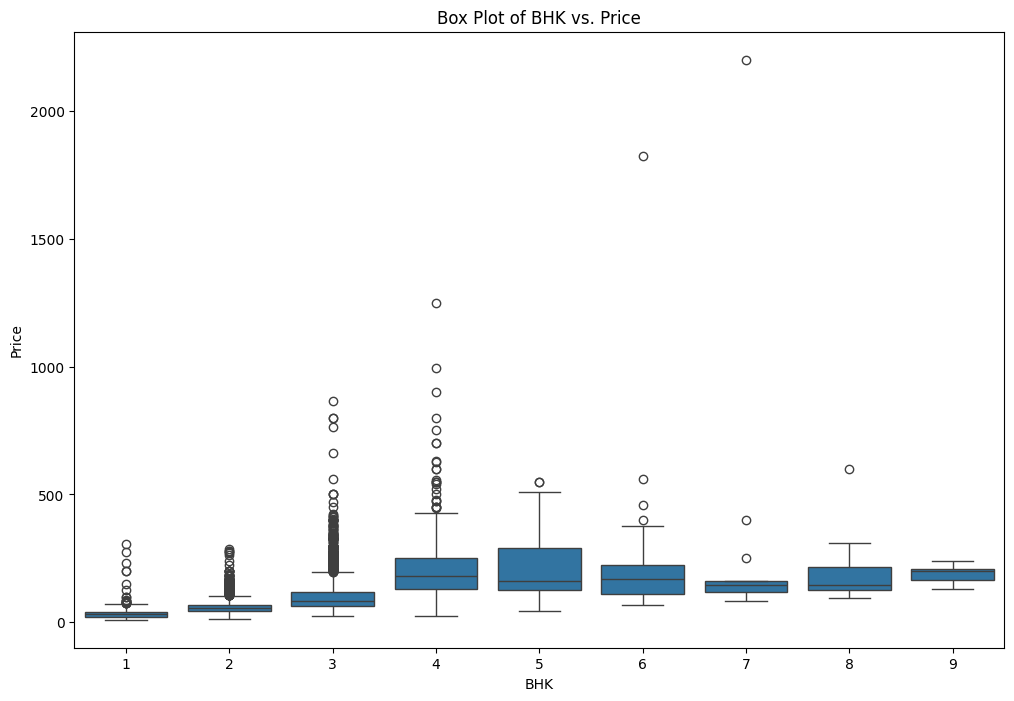

In [28]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='bhk',y='price',data=df)
plt.title('Box Plot of BHK vs. Price')
plt.xlabel('BHK')
plt.ylabel('Price')
plt.show()

#9.Encoding &Feature Preparation

In [29]:
df=df.drop('price_per_sqft',axis=1)
df.head()

,location,total_sqft,bath,balcony,price,bhk
0,Devarachikkanahalli,1250.0,2.0,3.0,44.0,3
1,Devarachikkanahalli,1250.0,2.0,2.0,40.0,2
2,Devarachikkanahalli,1200.0,2.0,2.0,83.0,2
3,Devarachikkanahalli,1170.0,2.0,2.0,40.0,2
4,Devarachikkanahalli,1425.0,2.0,2.0,65.0,3


In [30]:
dummies=pd.get_dummies(df['location'])
df=pd.concat([df,dummies],axis=1)
df=df.drop('location',axis=1)
df.head()


,total_sqft,bath,balcony,price,bhk,Devarachikkanahalli,1st Block Jayanagar,1st Block Koramangala,1st Phase JP Nagar,2nd Phase Judicial Layout,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,others
0,1250.0,2.0,3.0,44.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1250.0,2.0,2.0,40.0,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1200.0,2.0,2.0,83.0,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1170.0,2.0,2.0,40.0,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1425.0,2.0,2.0,65.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [31]:
X=df.drop('price',axis=1)
Y=df['price']

print(X.shape)
print(Y.shape)


(9745, 252)
(9745,)


In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)

(7796, 252)
(1949, 252)


#10.Model Training

1.Linear Regression

In [36]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(X_train,Y_train)


LinearRegression()

In [37]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

y_pred=lr.predict(X_test)
print("linear regression")
print(f"R2 score: {r2_score(Y_test,y_pred):.4f}")
print(f"MAE: {mean_absolute_error(Y_test,y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test,y_pred)):.2f}")

linear regression
R2 score: 0.8203
MAE: 17.86
RMSE: 33.23


2.Decision Tree & Random Forest

In [39]:
from sklearn.tree import DecisionTreeRegressor

dt= DecisionTreeRegressor(random_state=42)
dt.fit(X_train,Y_train)

y_pred_dt=dt.predict(X_test)

print("Decision tree")
print(f"R2 score: {r2_score(Y_test,y_pred_dt):.4f}")
print(f"MAE: {mean_absolute_error(Y_test,y_pred_dt):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test,y_pred_dt)):.2f}")


Decision tree
R2 score: 0.4399
MAE: 20.33
RMSE: 58.66


In [41]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, Y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print(f"R² Score:  {r2_score(Y_test, y_pred_rf):.4f}")
print(f"MAE:       {mean_absolute_error(Y_test, y_pred_rf):.2f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(Y_test, y_pred_rf)):.2f}")

Random Forest Results:
R² Score:  0.7445
MAE:       16.93
RMSE:      39.62


3.XGBoost

In [44]:
from xgboost import XGBRegressor

xgb=XGBRegressor(random_state=42)
xgb.fit(X_train,Y_train)

y_pred_xgb=xgb.predict(X_test)

print("XGBoost Results:")
print(f"R² Score:  {r2_score(Y_test, y_pred_xgb):.4f}")
print(f"MAE:       {mean_absolute_error(Y_test, y_pred_xgb):.2f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(Y_test, y_pred_xgb)):.2f}")

XGBoost Results:
R² Score:  0.7366
MAE:       16.55
RMSE:      40.23


In [45]:
from sklearn.model_selection import cross_val_score

models={
    'Linear Regression':lr,
    'Random Forest':rf,
    'XGBoost':xgb
}

for name,model in models.items():
  scores=cross_val_score(model,X,Y,cv=5,scoring='r2')
  print(f"{name}:")
  print(f" CV r2 Scores:{scores.round(4)}")
  print(f"Mean R2: {scores.mean():.4f} | Std: {scores.std():.4f}")
  print()

Linear Regression:
 CV r2 Scores:[0.5163 0.6781 0.5847 0.7648 0.6971]
Mean R2: 0.6482 | Std: 0.0875

Random Forest:
 CV r2 Scores:[0.5207 0.6548 0.5183 0.7578 0.7149]
Mean R2: 0.6333 | Std: 0.0985

XGBoost:
 CV r2 Scores:[0.5634 0.6844 0.4752 0.8098 0.626 ]
Mean R2: 0.6317 | Std: 0.1129



#11.Hyperparameter Tuning

In [47]:
from sklearn.model_selection import GridSearchCV

param_grid ={
    'n_estimators':[100,200],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}
grid_search=GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train,Y_train)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best Score: 0.7526


In [48]:
best_rf=grid_search.best_estimator_
y_pred_best=best_rf.predict(X_test)
print("Tuned Random Forest Results:")
print(f"R² Score:  {r2_score(Y_test, y_pred_best):.4f}")
print(f"MAE:       {mean_absolute_error(Y_test, y_pred_best):.2f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(Y_test, y_pred_best)):.2f}")


Tuned Random Forest Results:
R² Score:  0.7554
MAE:       16.57
RMSE:      38.77


#Final step

In [49]:
import pickle

with open('house_price_model.pkl','wb') as f:
  pickle.dump(best_rf,f)

print("Model saved successfully")

Model saved successfully


In [50]:
import shutil
shutil.copy('house_price_model.pkl',
'/content/drive/MyDrive/house_price_model.pkl')
print("Model saved to Google Drive!")

Model saved to Google Drive!
